# Business Understanding

The purpose of this project is to develop a deep learning system capable of automatically detecting plant diseases from images of plant leaves. Plant diseases are a major challenge in agriculture because they can significantly reduce crop yield and quality if not identified early. Many farmers rely on manual inspection or expert consultation to diagnose plant diseases, which can be expensive.

This project aims to use computer vision and deep learning techniques to create a model that can classify plant leaf images into different disease categories. By automating disease detection, the solution can assist farmers and agricultural experts in identifying plant diseases quickly and accurately.

### Stakeholders

Several groups could benefit from this system:

* **Agricultural organizations and researchers** – who may use such models to monitor crop health and improve disease management strategies.
* **Farmers** – who need quick and reliable ways to identify plant diseases in their crops.
* **Agricultural experts and agronomists** – who can use the system as a diagnostic support tool.
* **Technology developers** – who could integrate the model into mobile or web-based agricultural tools.

### Business Problem

The main problem addressed in this project is the difficulty of early and accurate plant disease identification. Delays in disease detection can lead to significant crop losses and economic impact for farmers. By building a machine learning model that can detect diseases from leaf images, the project aims to provide a scalable and accessible solution for disease diagnosis.

### Scope of the Project

The scope of this project includes:

* Building image classification models to identify plant diseases from leaf images.
* Training and evaluating two deep learning models: a **Custom Convolutional Neural Network (CNN)** and a **MobileNetV2 transfer learning model**.
* Saving the trained models for potential deployment in a real-world application.

### Data Sources

The project uses an image dataset containing labeled plant leaf images representing healthy plants and various disease classes. These images are used to train and evaluate the deep learning models.

### Expected Outcome

The expected outcome of this project is a trained model capable of accurately classifying plant diseases from images. The model can later be deployed in an application that allows users to upload a plant leaf image and receive a predicted disease category, helping support faster agricultural decision-making.


In [1]:
# import relevant libraries

import os
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import classification_report, confusion_matrix
import hashlib
from PIL import Image
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau



## Load Training Data & Validation Images

In [2]:
# Base directory
base_dir = "./plant_dataset"

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=f"{base_dir}/train",
    image_size=(128,128),
    batch_size=32,
    labels="inferred",
    label_mode="categorical", # one-hot encode labels
    color_mode="rgb",
    shuffle=True
)

# Load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=f"{base_dir}/val",
    image_size=(128,128),
    batch_size=32,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    shuffle=True
)

# Load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=f"{base_dir}/test",
    image_size=(128,128),
    batch_size=32,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    shuffle=False
)
class_names = train_dataset.class_names  
num_classes = len(class_names)

print("Number of classes:", num_classes)

# Print dataset sizes
print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 33 files belonging to 1 classes.
Number of classes: 38
Training batches: 2197
Validation batches: 550
Test batches: 2


In [3]:
print("Train classes:", os.listdir("./plant_dataset/train")[:5])
print("Val classes:", os.listdir("./plant_dataset/val")[:5])
print("Test classes:", os.listdir("./plant_dataset/test")[:5])

Train classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Val classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Test classes: ['all_test_images']


In [5]:
# Print number of classes and class names
print("Number of classes:", len(train_dataset.class_names))
print("\nClass indices:\n")
for index, class_name in enumerate(train_dataset.class_names):
    print(index, ":", class_name)

Number of classes: 38

Class indices:

0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy
4 : Blueberry___healthy
5 : Cherry_(including_sour)___Powdery_mildew
6 : Cherry_(including_sour)___healthy
7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 : Corn_(maize)___Common_rust_
9 : Corn_(maize)___Northern_Leaf_Blight
10 : Corn_(maize)___healthy
11 : Grape___Black_rot
12 : Grape___Esca_(Black_Measles)
13 : Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 : Grape___healthy
15 : Orange___Haunglongbing_(Citrus_greening)
16 : Peach___Bacterial_spot
17 : Peach___healthy
18 : Pepper,_bell___Bacterial_spot
19 : Pepper,_bell___healthy
20 : Potato___Early_blight
21 : Potato___Late_blight
22 : Potato___healthy
23 : Raspberry___healthy
24 : Soybean___healthy
25 : Squash___Powdery_mildew
26 : Strawberry___Leaf_scorch
27 : Strawberry___healthy
28 : Tomato___Bacterial_spot
29 : Tomato___Early_blight
30 : Tomato___Late_blight
31 : Tomato___Leaf_Mold
32 : To

## **Checking for Class Distribution if the number of images are balanced across the classes**

In [7]:
# Create a dictionary to hold counts
class_counts = {}

# Iterate through the dataset
for images, labels in train_dataset:
    # labels are one-hot encoded, convert to class index
    class_indices = tf.argmax(labels, axis=1).numpy()
    for idx in class_indices:
        class_counts[idx] = class_counts.get(idx, 0) + 1

# Map indices back to class names
class_names = train_dataset.class_names  # this exists in the tf.data.Dataset object
for idx, count in class_counts.items():
    print(f"{class_names[idx]} : {count}")

Grape___healthy : 1692
Peach___healthy : 1728
Tomato___Late_blight : 1851
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 1961
Squash___Powdery_mildew : 1736
Apple___healthy : 2008
Corn_(maize)___Common_rust_ : 1907
Grape___Black_rot : 1888
Corn_(maize)___healthy : 1859
Potato___Early_blight : 1939
Tomato___Target_Spot : 1827
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 1642
Apple___Black_rot : 1987
Apple___Apple_scab : 2016
Tomato___healthy : 1926
Pepper,_bell___Bacterial_spot : 1913
Pepper,_bell___healthy : 1988
Tomato___Early_blight : 1920
Grape___Esca_(Black_Measles) : 1920
Orange___Haunglongbing_(Citrus_greening) : 2010
Tomato___Septoria_leaf_spot : 1745
Potato___healthy : 1824
Potato___Late_blight : 1939
Blueberry___healthy : 1816
Tomato___Leaf_Mold : 1882
Strawberry___healthy : 1824
Strawberry___Leaf_scorch : 1774
Apple___Cedar_apple_rust : 1760
Cherry_(including_sour)___Powdery_mildew : 1683
Tomato___Bacterial_spot : 1702
Tomato___Spider_mites Two-spotted_spider_mite : 1741
Pe

## **Observation**
* **The dataset is well distributed across the classes, no severe skew hence no need for oversampling and class weights.**

## **Check for corrupt images**

In [8]:

splits = ["train", "val", "test"]
base_path = "./plant_dataset"

corrupted_images = []

for split in splits:
    split_path = os.path.join(base_path, split)
    
    # Loop through each class folder in the split
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue
        
        # Loop through all images in the class folder
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()  # Verify integrity
            except Exception:
                corrupted_images.append(img_path)

print(f"Total corrupted images found: {len(corrupted_images)}")
if corrupted_images:
    print("Some images are corrupted. Example:")
    print(corrupted_images[:5])
else:
    print("No corrupted images found.")

Total corrupted images found: 0
No corrupted images found.


### **Observation**
* **No corrupted images found.**

## **Data Augmentation to Training Dataset only**

In [10]:
# Create data augmentation, data augmentation improves generalization
data_augmentation = tf.keras.Sequential([                 
    layers.RandomFlip("horizontal_and_vertical"),    # Random Flip
    layers.RandomRotation(0.1),                     # Randomly rotates images by a fraction of 0.1, Prevents the model from overfitting to one fixed orientation
    layers.RandomZoom(0.1),                         # Random Zoom
])

# Prefetch for performance
train_dataset = train_dataset.prefetch(buffer_size=1)
val_dataset = val_dataset.prefetch(buffer_size=1)
test_dataset = test_dataset.prefetch(buffer_size=1)


## **Build CNN Model**

In [11]:

model = Sequential([
    data_augmentation,                        
    layers.Rescaling(1./225),                 # normalization done inside the model

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    # Conv Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    # Conv Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **Callbacks**

In [12]:
# Stop training if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,
    restore_best_weights=True)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    "cnn_model.keras",
    monitor='val_loss', 
    save_best_only=True,
    verbose=1)

# Reduce learning rate if the validation metric stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3)

## **Train the model**

In [13]:
history = model.fit(
    train_dataset,  
    validation_data=val_dataset,
    epochs=10,                # you can adjust
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.3204 - loss: 2.5630
Epoch 1: val_loss improved from None to 2.06907, saving model to cnn_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1643s 741ms/step - accuracy: 0.4439 - loss: 2.0286 - val_accuracy: 0.4034 - val_loss: 2.0691 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6402 - loss: 1.2373
Epoch 2: val_loss improved from 2.06907 to 1.85716, saving model to cnn_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4157s 2s/step - accuracy: 0.6707 - loss: 1.1265 - val_accuracy: 0.4993 - val_loss: 1.8572 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.7392 - loss: 0.8724
Epoch 3: val_loss did not improve from 1.85716
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1831s 834ms/step - accuracy: 0.7538 - loss: 0.8209 - val_accuracy: 0.5290 - val_loss: 1.8699 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 

In [14]:
# Save the model
model.save("cnn_model.keras")

## **Plot training history**

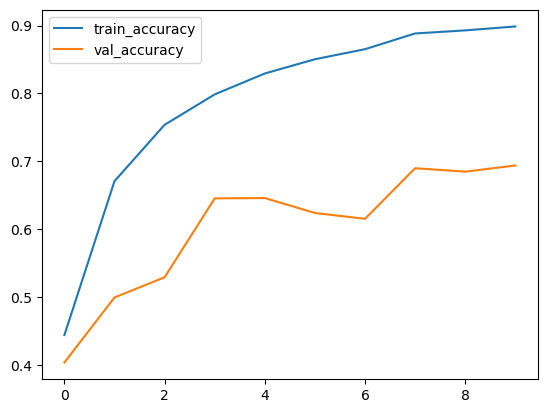

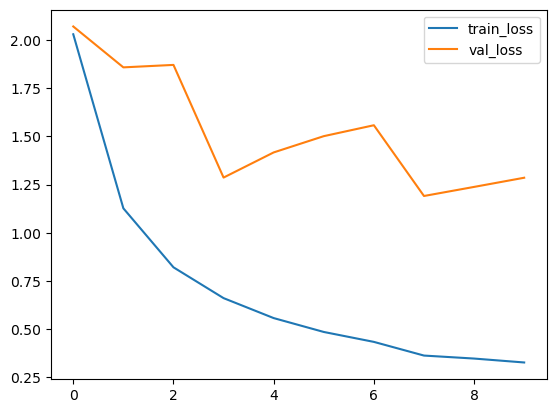

In [18]:
# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

## **Evaluate on test dataset**

In [19]:
# see how your model performs on unseen data

test_loss, test_acc = model.evaluate(test_dataset)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.0606 - loss: 488.1895
Test accuracy: 0.06060606241226196
Test loss: 488.1894836425781


## **TRANSFER LEARNING (MobileNetV2)**

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (128, 128)
NUM_CLASSES = 38  # from your dataset

# Load MobileNetV2 without top layers, pre-trained on ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base_model
base_model.trainable = False

# Add custom classification head
inputs = tf.keras.Input(shape=(128,128,3))
x = preprocess_input(inputs)                  # Preprocessing as MobileNet expects
x = base_model(x, training=False)             # Pass through base model
x = layers.GlobalAveragePooling2D()(x)       # Pool features
x = layers.Dropout(0.3)(x)                    # Dropout for regularization
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = tf.keras.Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 16s 2us/step


## **Compile the transfer learning model**

In [36]:
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),   # smaller LR for transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Train it with the augmented training dataset**

In [38]:
history_tl = model_tl.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.4192 - loss: 2.2669
Epoch 1: val_loss improved from 1.19051 to 0.52800, saving model to cnn_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1079s 484ms/step - accuracy: 0.6293 - loss: 1.3987 - val_accuracy: 0.8691 - val_loss: 0.5280 - learning_rate: 1.0000e-04
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8444 - loss: 0.5583
Epoch 2: val_loss improved from 0.52800 to 0.33982, saving model to cnn_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 990s 451ms/step - accuracy: 0.8586 - loss: 0.5028 - val_accuracy: 0.9080 - val_loss: 0.3398 - learning_rate: 1.0000e-04
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.8885 - loss: 0.3821
Epoch 3: val_loss improved from 0.33982 to 0.26664, saving model to cnn_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 930s 423ms/step - accuracy: 0.8940 - loss: 0.3625 - val_accuracy: 0.9253 - val_loss: 0.2666 - learning_rate: 1.0000e-04
Epoch 4/10
2197/2197 ━━━

In [39]:
# Save the model
model.save("mobilenetv2_plant_disease.keras")

## **Evaluate on test dataset**

In [40]:
test_loss, test_acc = model_tl.evaluate(test_dataset)
print("Test accuracy (Transfer Learning):", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.0909 - loss: 532.6246
Test accuracy (Transfer Learning): 0.09090909361839294


In [ ]:
## **Get predictions**

In [41]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model_tl.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


# **Final Model Selection**

The  **MobileNetV2** is selected as the final model for this project due to its higher accuracy, lower loss, and better overall performance in plant disease classification. It achieved approximately **94.4% training accuracy** and **95.4% validation accuracy**, with a **validation loss of about 0.152** by the final epoch. In comparison, the CNN model achieved  **89.8% training accuracy** but only **69.4% validation accuracy**, indicating weaker generalization to unseen data. 
